### Feature extractiom with TS Fresh package

In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tsfresh import extract_features
from tsfresh.feature_extraction import EfficientFCParameters
import librosa

def load_audio(file_path):
    """
    Load audio file and return the signal and sample rate.
    """
    signal, sr = librosa.load(file_path, sr=None)
    return signal, sr

def segment_audio(signal, sr, segment_duration=1):
    """
    Split the audio signal into equal-length segments.
    """
    segment_length = int(segment_duration * sr)
    segments = [signal[i:i + segment_length] for i in range(0, len(signal), segment_length)]
    return segments

def prepare_dataframe(segments):
    """
    Prepare a DataFrame for tsfresh.
    """
    data = []
    for idx, segment in enumerate(segments):
        for i, value in enumerate(segment):
            data.append({"id": idx, "time": i, "value": value})
    return pd.DataFrame(data)

def scale_features(features_df):
    """
    Scale features using sklearn's StandardScaler.
    """
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features_df)
    return pd.DataFrame(scaled_features, columns=features_df.columns, index=features_df.index)

def extract_audio_features_with_sklearn(file_path, segment_duration=1):
    """
    Extract features using sklearn and tsfresh.
    """
    signal, sr = load_audio(file_path)
    segments = segment_audio(signal, sr, segment_duration)
    df = prepare_dataframe(segments)

    # Extract features with tsfresh
    extracted_features = extract_features(df, column_id="id", column_sort="time", column_value="value", 
                                          default_fc_parameters=EfficientFCParameters())

    # Scale features with sklearn
    scaled_features = scale_features(extracted_features)
    return scaled_features

# Path to the audio file
file_path = r"C:\Users\Teresa\Desktop\MBBAS (2ºano)\Tese\Audio_samples\GE_F1_3ML - S.wav" 

# Extract features
features = extract_audio_features_with_sklearn(file_path, segment_duration=1)

# Display the extracted and scaled features
print(features.head())


Feature Extraction: 100%|██████████| 4/4 [00:03<00:00,  1.17it/s]

   value__variance_larger_than_standard_deviation  value__has_duplicate_max  \
0                                             0.0                 -0.577350   
1                                             0.0                 -0.577350   
2                                             0.0                 -0.577350   
3                                             0.0                  1.732051   

   value__has_duplicate_min  value__has_duplicate  value__sum_values  \
0                       0.0                   0.0           0.640458   
1                       0.0                   0.0           0.997712   
2                       0.0                   0.0          -1.610471   
3                       0.0                   0.0          -0.027699   

   value__abs_energy  value__mean_abs_change  value__mean_change  \
0          -0.559748               -0.522464           -0.016927   
1           1.731915                1.729839            1.201047   
2          -0.577000               -0.5


c:\Users\Teresa\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1137: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Teresa\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1142: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Teresa\anaconda3\Lib\site-packages\sklearn\utils\extmath.py:1162: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


### Replace NaNs or infinite values with zeros

In [5]:
features_cleaned = features.replace([np.inf, -np.inf], np.nan).fillna(0)

print(features_cleaned)

   value__variance_larger_than_standard_deviation  value__has_duplicate_max  \
0                                             0.0                 -0.577350   
1                                             0.0                 -0.577350   
2                                             0.0                 -0.577350   
3                                             0.0                  1.732051   

   value__has_duplicate_min  value__has_duplicate  value__sum_values  \
0                       0.0                   0.0           0.640458   
1                       0.0                   0.0           0.997712   
2                       0.0                   0.0          -1.610471   
3                       0.0                   0.0          -0.027699   

   value__abs_energy  value__mean_abs_change  value__mean_change  \
0          -0.559748               -0.522464           -0.016927   
1           1.731915                1.729839            1.201047   
2          -0.577000               -0.5

In [16]:
# Check column names and their data types
print(features_cleaned.dtypes)


value__variance_larger_than_standard_deviation              float64
value__has_duplicate_max                                    float64
value__has_duplicate_min                                    float64
value__has_duplicate                                        float64
value__sum_values                                           float64
                                                             ...   
value__permutation_entropy__dimension_5__tau_1              float64
value__permutation_entropy__dimension_6__tau_1              float64
value__permutation_entropy__dimension_7__tau_1              float64
value__query_similarity_count__query_None__threshold_0.0    float64
value__mean_n_absolute_max__number_of_maxima_7              float64
Length: 777, dtype: object


In [17]:
# Check for columns with constant values (i.e., no variation)
constant_columns = features_cleaned.columns[features_cleaned.nunique() == 1]
print("Constant Columns: ", constant_columns)

# Check for columns with missing values
missing_values = features_cleaned.isnull().sum()
columns_with_missing = missing_values[missing_values > 0]
print(f"Columns with missing values: {columns_with_missing}")


Constant Columns:  Index(['value__variance_larger_than_standard_deviation',
       'value__has_duplicate_min', 'value__has_duplicate', 'value__median',
       'value__symmetry_looking__r_0.0', 'value__symmetry_looking__r_0.05',
       'value__symmetry_looking__r_0.1',
       'value__symmetry_looking__r_0.15000000000000002',
       'value__symmetry_looking__r_0.2', 'value__symmetry_looking__r_0.25',
       'value__symmetry_looking__r_0.30000000000000004',
       'value__symmetry_looking__r_0.35000000000000003',
       'value__symmetry_looking__r_0.4', 'value__symmetry_looking__r_0.45',
       'value__symmetry_looking__r_0.5', 'value__symmetry_looking__r_0.55',
       'value__symmetry_looking__r_0.6000000000000001',
       'value__symmetry_looking__r_0.65',
       'value__symmetry_looking__r_0.7000000000000001',
       'value__symmetry_looking__r_0.75', 'value__symmetry_looking__r_0.8',
       'value__symmetry_looking__r_0.8500000000000001',
       'value__symmetry_looking__r_0.9',
     

In [18]:
# Print all column names
for col in features_cleaned.columns:
    print(col)


value__variance_larger_than_standard_deviation
value__has_duplicate_max
value__has_duplicate_min
value__has_duplicate
value__sum_values
value__abs_energy
value__mean_abs_change
value__mean_change
value__mean_second_derivative_central
value__median
value__mean
value__length
value__standard_deviation
value__variation_coefficient
value__variance
value__skewness
value__kurtosis
value__root_mean_square
value__absolute_sum_of_changes
value__longest_strike_below_mean
value__longest_strike_above_mean
value__count_above_mean
value__count_below_mean
value__last_location_of_maximum
value__first_location_of_maximum
value__last_location_of_minimum
value__first_location_of_minimum
value__percentage_of_reoccurring_values_to_all_values
value__percentage_of_reoccurring_datapoints_to_all_datapoints
value__sum_of_reoccurring_values
value__sum_of_reoccurring_data_points
value__ratio_value_number_to_time_series_length
value__maximum
value__absolute_maximum
value__minimum
value__benford_correlation
value__t

In [19]:
# Check the shape of the dataset
print(features_cleaned.shape)


(4, 777)


### Printing the headers of the columns

In [21]:
print(list(features_cleaned))

['value__variance_larger_than_standard_deviation', 'value__has_duplicate_max', 'value__has_duplicate_min', 'value__has_duplicate', 'value__sum_values', 'value__abs_energy', 'value__mean_abs_change', 'value__mean_change', 'value__mean_second_derivative_central', 'value__median', 'value__mean', 'value__length', 'value__standard_deviation', 'value__variation_coefficient', 'value__variance', 'value__skewness', 'value__kurtosis', 'value__root_mean_square', 'value__absolute_sum_of_changes', 'value__longest_strike_below_mean', 'value__longest_strike_above_mean', 'value__count_above_mean', 'value__count_below_mean', 'value__last_location_of_maximum', 'value__first_location_of_maximum', 'value__last_location_of_minimum', 'value__first_location_of_minimum', 'value__percentage_of_reoccurring_values_to_all_values', 'value__percentage_of_reoccurring_datapoints_to_all_datapoints', 'value__sum_of_reoccurring_values', 'value__sum_of_reoccurring_data_points', 'value__ratio_value_number_to_time_series_l

In [22]:
for column in features_cleaned.columns:
    print(column)

value__variance_larger_than_standard_deviation
value__has_duplicate_max
value__has_duplicate_min
value__has_duplicate
value__sum_values
value__abs_energy
value__mean_abs_change
value__mean_change
value__mean_second_derivative_central
value__median
value__mean
value__length
value__standard_deviation
value__variation_coefficient
value__variance
value__skewness
value__kurtosis
value__root_mean_square
value__absolute_sum_of_changes
value__longest_strike_below_mean
value__longest_strike_above_mean
value__count_above_mean
value__count_below_mean
value__last_location_of_maximum
value__first_location_of_maximum
value__last_location_of_minimum
value__first_location_of_minimum
value__percentage_of_reoccurring_values_to_all_values
value__percentage_of_reoccurring_datapoints_to_all_datapoints
value__sum_of_reoccurring_values
value__sum_of_reoccurring_data_points
value__ratio_value_number_to_time_series_length
value__maximum
value__absolute_maximum
value__minimum
value__benford_correlation
value__t

In [23]:
print(len(column))

46


### Applying seaborn to visualize data

#### Heatmap

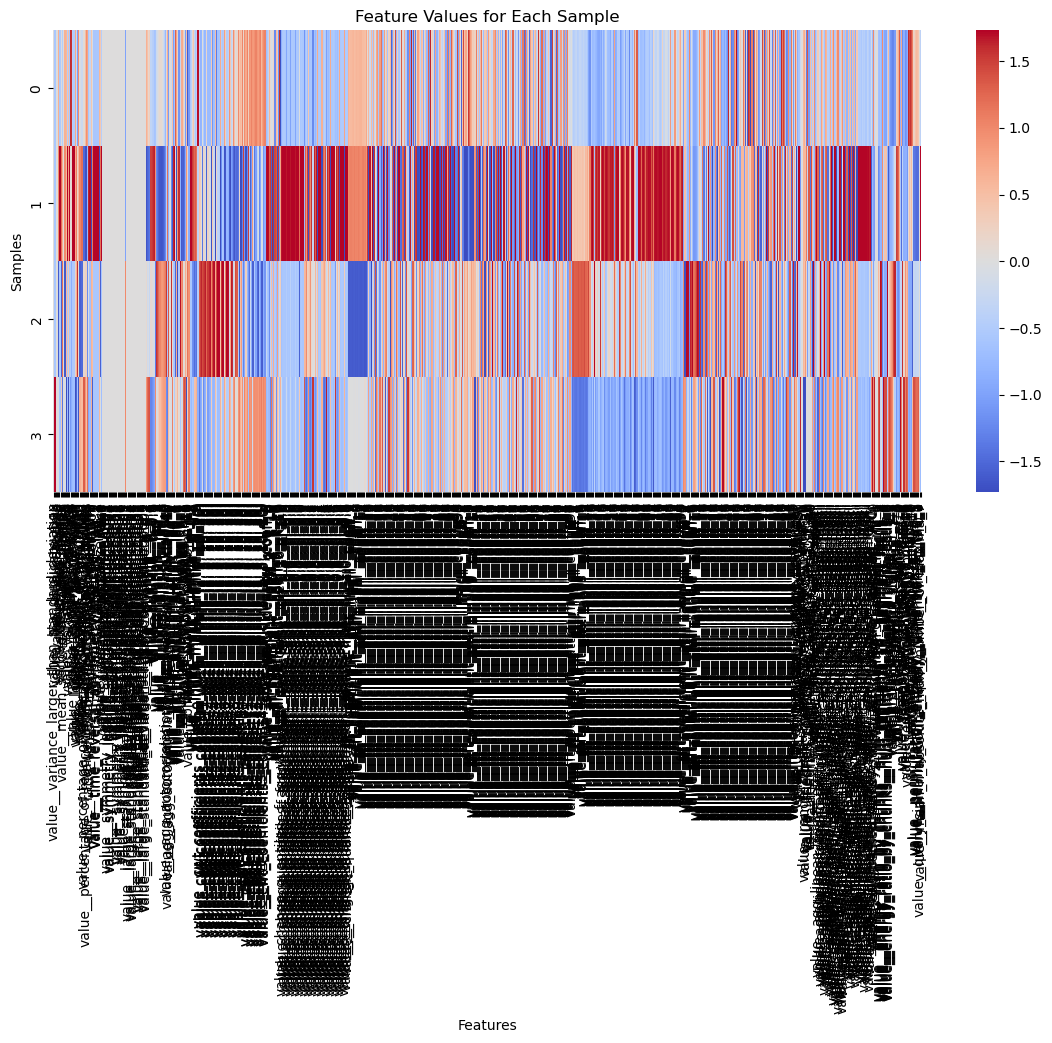

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.heatmap(features_cleaned, cmap='coolwarm', cbar=True, xticklabels=True)
plt.title('Feature Values for Each Sample')
plt.xlabel('Features')
plt.ylabel('Samples')
plt.show()


Note: Need to downsample or use other method to visualize the data

#### Clusters

c:\Users\Teresa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


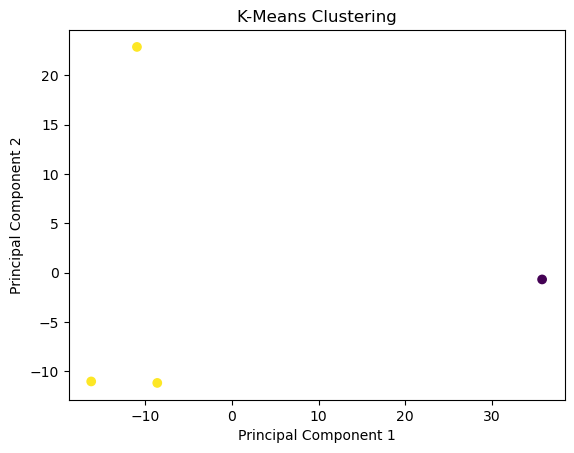

In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Define the number of clusters
k = 2

# Apply K-Means clustering
kmeans = KMeans(n_clusters=k, random_state=42)
features_cleaned['Cluster'] = kmeans.fit_predict(features_cleaned)

# Plot the results (we'll just plot the 2 principal components)
plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=features_cleaned['Cluster'], cmap='viridis')
plt.title('K-Means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
